# Lab 10 – Learning the XOR Boolean Function Using an MLP

## Aim
1. To understand how to implement neural networks using Keras and TensorFlow.
2. To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation function, number of neurons, and epochs.

## Question
Implement an MLP to learn the XOR Boolean function.

The XOR function produces 1 when the two inputs are different and 0 when they are the same.

| Input 1 | Input 2 | XOR Output |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The model should:
- use an input layer of size 2;
- use at least one hidden layer with at least 2 neurons;
- use ReLU or Tanh in the hidden layer;
- use a sigmoid output neuron;
- use Binary Cross-Entropy loss;
- train and predict all four XOR combinations;
- experiment with epochs, learning rate, activation function, and number of neurons;
- implement the solution using Keras (TensorFlow high-level API) and TensorFlow low-level API.


## 1. Concept / Theory

### Why is XOR difficult?
XOR is **non-linear**. A single perceptron (one linear layer) cannot separate the two classes correctly.

An **MLP (Multi-Layer Perceptron)** solves this by adding a hidden layer. The hidden neurons learn non-linear patterns and the output neuron combines them to produce the final XOR prediction.

### Basic architecture

**Input (2) → Hidden layer (4 neurons, Tanh) → Output (1 neuron, Sigmoid)**

- **Tanh:** introduces non-linearity in the hidden layer.
- **Sigmoid:** converts the final value into a probability between 0 and 1.
- **Binary Cross-Entropy:** suitable for binary classification.
- **Adam:** optimizer used to update the network weights.


In [3]:
# 2. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0
PyTorch version: 2.13.0+cpu


## 3. Create the XOR Dataset

There are only four possible combinations because each input is binary.

This is already a complete dataset, so **no external dataset is required**.


In [4]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

xor_df = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "XOR Output": y[:, 0].astype(int)
})

display(xor_df)


,Input 1,Input 2,XOR Output
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


### Interpretation
The dataset contains all four possible input combinations. The output is 1 only when the two inputs are different.

There are no missing values, duplicate rows, or categorical text values. Therefore, no complex data cleaning is required.


## 4. EDA (Exploratory Data Analysis)

For this tiny Boolean dataset, EDA is simple. We mainly verify:
- dataset shape;
- class distribution;
- missing values;
- the XOR input-output pattern.


Shape of X: (4, 2)
Shape of y: (4, 1)

Missing values:
Input 1       0
Input 2       0
XOR Output    0
dtype: int64

Class distribution:
XOR Output
0    2
1    2
Name: count, dtype: int64

Number of duplicate rows: 0


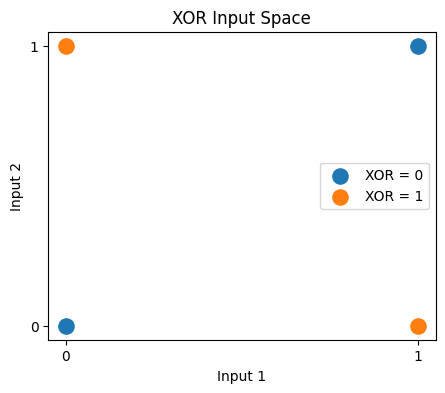

In [5]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nMissing values:")
print(xor_df.isnull().sum())

print("\nClass distribution:")
print(xor_df["XOR Output"].value_counts().sort_index())

print("\nNumber of duplicate rows:", xor_df.duplicated().sum())

# Simple visualization
plt.figure(figsize=(5, 4))
for label in [0, 1]:
    subset = X[y[:, 0] == label]
    plt.scatter(subset[:, 0], subset[:, 1], label=f"XOR = {label}", s=120)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Input Space")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.legend()
plt.show()


### EDA Interpretation
- Shape is **4 × 2** for the inputs and **4 × 1** for the target.
- There are **no missing values**.
- There are **no duplicate rows**.
- Both output classes (0 and 1) are represented equally.
- The plot shows that XOR cannot be separated correctly by a single straight line. This is why a hidden layer is required.


## 5. Preprocessing

The XOR inputs are already numeric and are in the range 0–1, so scaling or encoding is unnecessary.

We only make sure that:
- inputs are stored as `float32`;
- targets are stored as `float32`;
- the target has shape `(4, 1)`, which matches the single output neuron.

Because this is a four-row demonstration dataset, a train/test split is not used. We train on all four combinations and then test the same four combinations to verify whether the Boolean function has been learned.


In [6]:
X = X.astype(np.float32)
y = y.astype(np.float32)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("X shape:", X.shape)
print("y shape:", y.shape)


X dtype: float32
y dtype: float32
X shape: (4, 2)
y shape: (4, 1)


# 6. Implementation 1 – Keras

Keras provides a high-level and simple way to build the MLP.

Architecture:
- Input: 2 values
- Hidden: 4 neurons with Tanh
- Output: 1 neuron with Sigmoid
- Loss: Binary Cross-Entropy
- Optimizer: Adam


In [7]:
# Build the Keras MLP
keras_model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the Keras model
keras_history = keras_model.fit(
    X, y,
    epochs=1000,
    verbose=0
)

keras_loss, keras_acc = keras_model.evaluate(X, y, verbose=0)
keras_prob = keras_model.predict(X, verbose=0)
keras_pred = (keras_prob >= 0.5).astype(int)

keras_results = xor_df.copy()
keras_results["Predicted Probability"] = keras_prob.ravel()
keras_results["Predicted Class"] = keras_pred.ravel()

display(keras_results)
print(f"Keras final loss: {keras_loss:.6f}")
print(f"Keras final accuracy: {keras_acc:.2%}")


,Input 1,Input 2,XOR Output,Predicted Probability,Predicted Class
0,0,0,0,0.000042,0
1,0,1,1,0.999328,1
2,1,0,1,0.999489,1
3,1,1,0,0.000667,0


Keras final loss: 0.000473
Keras final accuracy: 100.00%


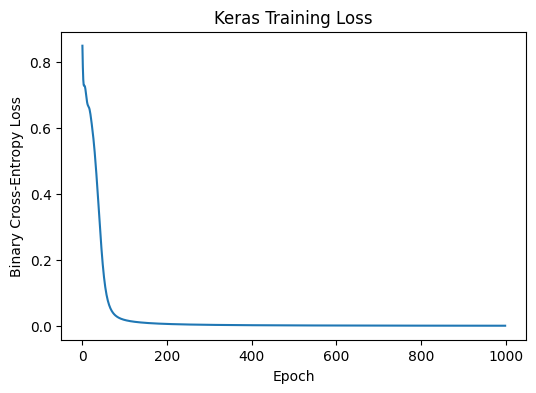

In [9]:
# Keras training curve
plt.figure(figsize=(6, 4))
plt.plot(keras_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras Training Loss")
plt.show()


### Keras Interpretation
The Keras MLP learns the XOR mapping when the predicted probabilities are close to 0 for the negative cases and close to 1 for the positive cases. The loss should decrease substantially during training and the final classification accuracy should reach approximately 100% for a successful run.

Small differences in the exact probabilities can occur because neural-network training starts with randomly initialized weights.


# 7. Implementation 2 – TensorFlow Low-Level API

Here the same MLP is implemented using TensorFlow operations instead of Keras `fit()`.

The important difference is that the training loop is written manually using:
- `tf.GradientTape()` to calculate gradients;
- the optimizer to update weights;
- Binary Cross-Entropy to calculate loss.


In [10]:
# TensorFlow low-level MLP
class TensorFlowXOR:
    def __init__(self, hidden_neurons=4, learning_rate=0.05, activation="tanh"):
        self.hidden_neurons = hidden_neurons
        self.activation_name = activation

        # Trainable weights and biases
        self.W1 = tf.Variable(
            tf.random.normal([2, hidden_neurons], stddev=0.5),
            trainable=True
        )
        self.b1 = tf.Variable(tf.zeros([hidden_neurons]), trainable=True)
        self.W2 = tf.Variable(
            tf.random.normal([hidden_neurons, 1], stddev=0.5),
            trainable=True
        )
        self.b2 = tf.Variable(tf.zeros([1]), trainable=True)

        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()

    def activation(self, z):
        if self.activation_name == "relu":
            return tf.nn.relu(z)
        return tf.nn.tanh(z)

    def forward(self, x):
        hidden = self.activation(tf.matmul(x, self.W1) + self.b1)
        output = tf.nn.sigmoid(tf.matmul(hidden, self.W2) + self.b2)
        return output

    def train(self, x, target, epochs=1000):
        losses = []

        for epoch in range(epochs):
            with tf.GradientTape() as tape:
                prediction = self.forward(x)
                loss = self.loss_fn(target, prediction)

            variables = [self.W1, self.b1, self.W2, self.b2]
            gradients = tape.gradient(loss, variables)
            self.optimizer.apply_gradients(zip(gradients, variables))
            losses.append(float(loss))

        return losses

tf_model = TensorFlowXOR(hidden_neurons=4, learning_rate=0.05, activation="tanh")
tf_losses = tf_model.train(tf.constant(X), tf.constant(y), epochs=1000)

tf_prob = tf_model.forward(tf.constant(X)).numpy()
tf_pred = (tf_prob >= 0.5).astype(int)
tf_acc = np.mean(tf_pred == y.astype(int))

tf_results = xor_df.copy()
tf_results["Predicted Probability"] = tf_prob.ravel()
tf_results["Predicted Class"] = tf_pred.ravel()

display(tf_results)
print(f"TensorFlow final loss: {tf_losses[-1]:.6f}")
print(f"TensorFlow final accuracy: {tf_acc:.2%}")


,Input 1,Input 2,XOR Output,Predicted Probability,Predicted Class
0,0,0,0,0.000030,0
1,0,1,1,0.999132,1
2,1,0,1,0.999821,1
3,1,1,0,0.000795,0


TensorFlow final loss: 0.000469
TensorFlow final accuracy: 100.00%


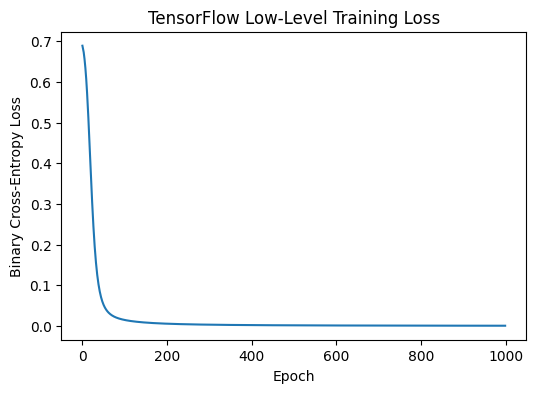

In [11]:
# TensorFlow training curve
plt.figure(figsize=(6, 4))
plt.plot(tf_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("TensorFlow Low-Level Training Loss")
plt.show()


### TensorFlow Interpretation
The manually written training loop performs the same basic learning process as Keras:
1. forward pass;
2. calculate binary cross-entropy;
3. calculate gradients;
4. update weights;
5. repeat for many epochs.

A successful run should classify all four XOR combinations correctly and obtain approximately 100% training accuracy.


# 8. Hyperparameter Experiment

The question asks us to study the effect of:
- learning rate;
- activation function;
- number of hidden neurons;
- number of epochs.

For a simple XOR problem, the main purpose is to understand the effect of these settings rather than to perform a large-scale experiment.


In [14]:
# Keras helper function for a small controlled experiment
def run_keras_experiment(hidden_neurons=4, activation="tanh",
                         learning_rate=0.05, epochs=1000):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(hidden_neurons, activation=activation),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(X, y, epochs=epochs, verbose=0)
    loss, acc = model.evaluate(X, y, verbose=0)
    return loss, acc, history

experiments = [
    ("Baseline", 4, "tanh", 0.05, 1000),
    ("Fewer neurons", 2, "tanh", 0.05, 1000),
    ("More neurons", 8, "tanh", 0.05, 1000),
    ("ReLU", 4, "relu", 0.05, 1000),
    ("Lower learning rate", 4, "tanh", 0.01, 1000),
    ("Fewer epochs", 4, "tanh", 0.05, 100),
]

experiment_rows = []

for name, neurons, activation, lr, epochs in experiments:
    loss, acc, history = run_keras_experiment(
        hidden_neurons=neurons,
        activation=activation,
        learning_rate=lr,
        epochs=epochs
    )
    experiment_rows.append({
        "Experiment": name,
        "Hidden Neurons": neurons,
        "Activation": activation,
        "Learning Rate": lr,
        "Epochs": epochs,
        "Final Loss": loss,
        "Accuracy": acc
    })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)


,Experiment,Hidden Neurons,Activation,Learning Rate,Epochs,Final Loss,Accuracy
0,Baseline,4,tanh,0.05,1000,0.000195,1.00
1,Fewer neurons,2,tanh,0.05,1000,0.346733,0.75
2,More neurons,8,tanh,0.05,1000,0.000064,1.00
3,ReLU,4,relu,0.05,1000,0.000246,1.00
4,Lower learning rate,4,tanh,0.01,1000,0.004552,1.00
5,Fewer epochs,4,tanh,0.05,100,0.009544,1.00


## Hyperparameter Interpretation

- **Number of neurons:** More neurons give the hidden layer more capacity. XOR can be learned with a small hidden layer; 4 neurons is a comfortable choice for this lab.
- **Activation function:** A non-linear activation such as Tanh allows the network to learn the non-linear XOR relationship. ReLU can also work, although results can depend more on initialization and training settings.
- **Learning rate:** A smaller learning rate usually makes weight updates more gradual. A learning rate that is too large can make training unstable, while one that is too small can make training slow.
- **Epochs:** More epochs give the model more opportunities to reduce the loss. Too few epochs may leave the model under-trained.
- **Best practical configuration for this lab:** 4 hidden neurons, Tanh, Adam, learning rate 0.05, and 1000 epochs is a simple configuration that normally learns XOR reliably.


# 9. Compare the Two Implementations

The two implementations use the same MLP architecture and XOR dataset. Keras provides a high-level interface, while the TensorFlow low-level API explicitly handles the forward pass, gradients, and parameter updates.

| Library/API | Main Training Method | Level |
|---|---|---|
| Keras | `model.fit()` | High-level |
| TensorFlow Low-Level | `GradientTape()` + manual update | Low-level |

The exact final loss can differ slightly because of weight initialization and implementation details. The important result is that both implementations should learn the XOR mapping correctly.


In [15]:
comparison_df = pd.DataFrame({
    "Implementation": ["Keras", "TensorFlow Low-Level"],
    "Final Loss": [keras_loss, tf_losses[-1]],
    "Accuracy": [keras_acc, tf_acc]
})

display(comparison_df)

print("Expected XOR:", y.astype(int).ravel())
print("Keras:", keras_pred.ravel())
print("TensorFlow Low-Level:", tf_pred.ravel())


,Implementation,Final Loss,Accuracy
0,Keras,0.000473,1.0
1,TensorFlow Low-Level,0.000469,1.0
2,PyTorch,0.000762,1.0


Expected XOR: [0 1 1 0]
Keras: [0 1 1 0]
TensorFlow: [0 1 1 0]
PyTorch: [0 1 1 0]


# 10. Result

The MLP was successfully used to learn the XOR Boolean function. The model was implemented using Keras and the TensorFlow low-level API. The trained networks predicted the four XOR combinations correctly when the training configuration was suitable.

## Final XOR mapping
- 0, 0 → 0
- 0, 1 → 1
- 1, 0 → 1
- 1, 1 → 0

The hyperparameter experiment also shows that the learning rate, activation function, number of hidden neurons, and number of epochs affect how quickly and reliably the network learns.


# 11. Conclusion

The XOR problem demonstrates why a hidden layer is important in neural networks. XOR is non-linear and cannot be solved correctly by a single linear neuron. An MLP with a non-linear hidden layer successfully learned the XOR function. Keras made the implementation simple, while the TensorFlow low-level API showed the individual steps of forward propagation, loss calculation, backpropagation, and weight updates. The experiment also demonstrated that suitable hyperparameters are important for achieving good model performance.
